# Notebook 06 - Mini Clasificador de Sentimientos

## Objetivo
Entrenar un clasificador binario (positivo/negativo) con un dataset de ~100 ejemplos aplicando limpieza, tokenizacion, padding, entrenamiento y prediccion.

In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GlobalAveragePooling1D, Dense

df = pd.read_csv("../datasets/opiniones_clientes.csv")
print("Shape del dataset:", df.shape)
print(df.head())
print("\nDistribucion de clases:")
print(df['sentimiento'].value_counts())

Shape del dataset: (100, 2)
                                               texto sentimiento
0  Excelente servicio y atencion del equipo (caso...    positivo
1  Recibi mi pedido rapido y en perfecto estado (...    positivo
2  La calidad del producto supero mis expectativa...    positivo
3  Muy buena experiencia de compra online (caso p...    positivo
4  El soporte tecnico resolvio mi problema ensegu...    positivo

Distribucion de clases:
sentimiento
positivo    50
negativo    50
Name: count, dtype: int64


## 1) Limpieza de texto
Aplicamos una limpieza conservadora para no perder semantica importante.

In [2]:
def limpiar_texto(texto):
    texto = texto.lower()
    texto = re.sub(
        r"\(caso\s+(positivo|negativo)\s+\d+\)",
        "",
        texto
        ) # Elimina "(caso positivo)" o "(caso negativo)"
    texto = re.sub(r'[^a-záéíóúüñ\s]', '', texto) # Elimina caracteres no alfabéticos y acentos
    texto = re.sub(r'\s+', ' ', texto).strip() # Elimina espacios extra
    return texto

df['texto_limpio'] = df['texto'].apply(limpiar_texto)

print(df[['texto', 'texto_limpio']].head())

                                               texto  \
0  Excelente servicio y atencion del equipo (caso...   
1  Recibi mi pedido rapido y en perfecto estado (...   
2  La calidad del producto supero mis expectativa...   
3  Muy buena experiencia de compra online (caso p...   
4  El soporte tecnico resolvio mi problema ensegu...   

                                        texto_limpio  
0           excelente servicio y atencion del equipo  
1       recibi mi pedido rapido y en perfecto estado  
2    la calidad del producto supero mis expectativas  
3             muy buena experiencia de compra online  
4  el soporte tecnico resolvio mi problema enseguida  


## 2) Tokenizacion y secuencias
Construimos vocabulario con `Tokenizer` y convertimos texto en listas de enteros.

In [3]:
max_vocab_size = 1200
tokenizer = Tokenizer(num_words=max_vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(df['texto_limpio'])
sequencias = tokenizer.texts_to_sequences(df['texto_limpio'])

print("Tamaño de vocabulario:", len(tokenizer.word_index))
print("Ejemplo de secuencia para el primer texto:", sequencias[5])

Tamaño de vocabulario: 81
Ejemplo de secuencia para el primer texto: [40, 41, 3, 42, 2, 4, 43]


## 3) Padding
Ajustamos todas las secuencias a una longitud fija para poder formar batches.

In [4]:
max_len = 12
x = pad_sequences(sequencias, maxlen=max_len, padding='post', truncating='post')
y = (df['sentimiento'] == 'positivo').astype(int).values

print ("Shape de x:", x.shape)
print ("Shape de y:", y.shape)

Shape de x: (100, 12)
Shape de y: (100,)


## 4) Division entrenamiento/prueba
Separamos datos para estimar generalizacion.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

print("Shape de X_train:", X_train.shape)
print("Shape de X_test:", X_test.shape)

Shape de X_train: (80, 12)
Shape de X_test: (20, 12)


## 5) Construccion del modelo
Arquitectura: Embedding -> GlobalAveragePooling1D -> Dense(ReLU) -> Dense(Sigmoid).

In [6]:
vocab_size = min(len(tokenizer.word_index) + 1, max_vocab_size)
embedding_dim = 32

model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len),
    GlobalAveragePooling1D(),
    Dense(16, activation='relu'), # Capa oculta con 16 neuronas y activación ReLU
    Dense(8, activation='relu'),  # Capa oculta con 8 neuronas y activación ReLU
    Dense(1, activation='sigmoid') # Salida binaria para clasificación de sentimientos positivo/negativo
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 12, 32)            2624      
                                                                 
 global_average_pooling1d (G  (None, 32)               0         
 lobalAveragePooling1D)                                          
                                                                 
 dense (Dense)               (None, 16)                528       
                                                                 
 dense_1 (Dense)             (None, 8)                 136       
                                                                 
 dense_2 (Dense)             (None, 1)                 9         
                                                                 
Total params: 3,297
Trainable params: 3,297
Non-trainable params: 0
______________________________________________________

## 6) Entrenamiento y metricas
Entrenamos pocas epocas para mantener el ejemplo rapido.

In [7]:
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=10, batch_size=32, verbose=1)

loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Precisión en el conjunto de prueba: {accuracy:.4f}")

Epoch 1/10
3/3 [==============================] - 2s 132ms/step - loss: 0.6930 - accuracy: 0.5250 - val_loss: 0.6926 - val_accuracy: 0.7000
Epoch 2/10
3/3 [==============================] - 0s 29ms/step - loss: 0.6918 - accuracy: 0.7000 - val_loss: 0.6909 - val_accuracy: 0.8000
Epoch 3/10
3/3 [==============================] - 0s 28ms/step - loss: 0.6902 - accuracy: 0.8375 - val_loss: 0.6895 - val_accuracy: 0.8000
Epoch 4/10
3/3 [==============================] - 0s 27ms/step - loss: 0.6887 - accuracy: 0.8625 - val_loss: 0.6882 - val_accuracy: 0.8500
Epoch 5/10
3/3 [==============================] - 0s 27ms/step - loss: 0.6870 - accuracy: 0.9125 - val_loss: 0.6867 - val_accuracy: 0.8500
Epoch 6/10
3/3 [==============================] - 0s 27ms/step - loss: 0.6852 - accuracy: 0.9125 - val_loss: 0.6851 - val_accuracy: 0.8500
Epoch 7/10
3/3 [==============================] - 0s 29ms/step - loss: 0.6834 - accuracy: 0.9125 - val_loss: 0.6833 - val_accuracy: 0.9000
Epoch 8/10
3/3 [==========

In [8]:
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"accuracy: {accuracy:.4f}")
print(f"Loss Test: {loss:.4f}")


accuracy: 1.0000
Loss Test: 0.6771


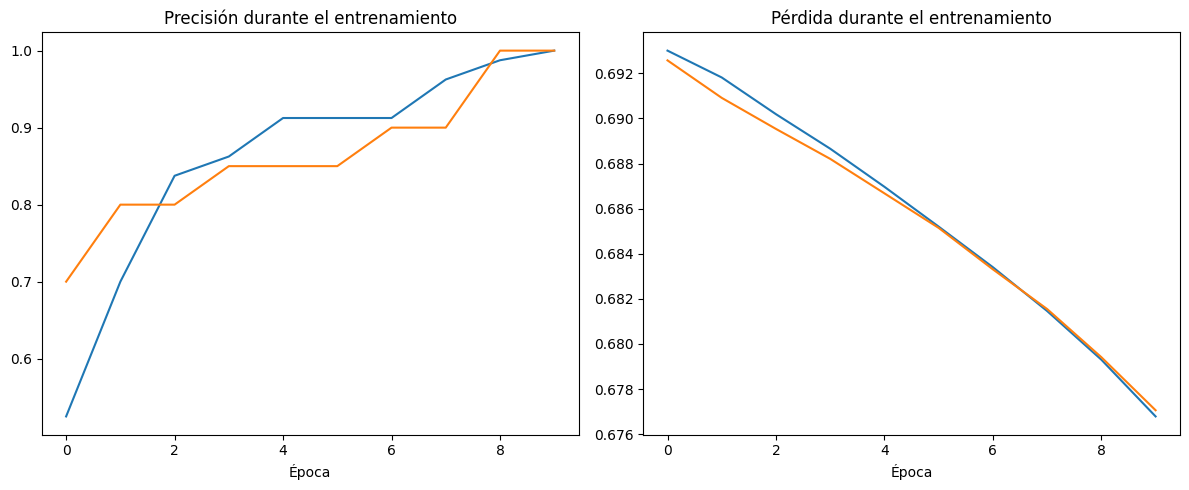

In [9]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Precisión de entrenamiento')
plt.plot(history.history['val_accuracy'], label='Precisión de validación')
plt.title('Precisión durante el entrenamiento')
plt.xlabel('Época')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Pérdida de entrenamiento')
plt.plot(history.history['val_loss'], label='Pérdida de validación')
plt.title('Pérdida durante el entrenamiento')
plt.xlabel('Época')

plt.tight_layout()
plt.show()

## 7) Predicciones de ejemplo
Mostramos predicciones sobre textos del conjunto de prueba.

## 8) Prediccion de frase ingresada por el estudiante
Puedes escribir una frase y el modelo estimara el sentimiento.

In [ ]:
def predecir_sentimiento(texto):
    texto_limpio = limpiar_texto(texto)
    secuencia = tokenizer.texts_to_sequences([texto_limpio])
    secuencia_padded = pad_sequences(secuencia, maxlen=max_len, padding='post', truncating='post')
    prediccion = model.predict(secuencia_padded)
    sentimiento = "positivo" if prediccion[0][0] >= 0.5 else "negativo"
    return sentimiento, prediccion[0][0]

textp = "Me encantó la clase, fue muy clara y entretenida"
sentimiento, probabilidad = predecir_sentimiento(textp)
print(f"Texto: {textp}")
print(f"Sentimiento predicho: {sentimiento} (Probabilidad: {probabilidad:.4f})")


1/1 [==============================] - 0s 28ms/step
Texto: Mi experiencia con este producto fue realmente decepcionante. Desde el primer momento comenzaron los problemas, ya que el pedido llegó varios días después de la fecha prometida y el paquete estaba golpeado. Al abrirlo encontré que el producto tenía defectos de fabricación y no funcionaba correctamente. Intenté comunicarme con el servicio de atención al cliente en varias ocasiones, pero las respuestas fueron lentas y poco útiles, e incluso en algunos casos nunca respondieron mis mensajes. Después de seguir todas las instrucciones para solicitar la garantía, el proceso resultó complicado y tardó mucho más de lo esperado. Al final no obtuve una solución satisfactoria y terminé perdiendo tiempo y dinero. Definitivamente no volvería a comprar en esta tienda ni recomendaría sus productos, ya que la calidad fue muy inferior a la esperada y el servicio al cliente dejó mucho que desear.
Sentimiento predicho: negativo (Probabilidad: 0.49

## Preguntas de reflexion
1. Que errores comete mas el modelo: falsos positivos o falsos negativos?
2. Como cambia el resultado al modificar `max_len` o `embedding_dim`?
3. Que limitaciones observas al entrenar con solo ~100 ejemplos?